# Category Recall Rate

> Plot scalar recall rates restricted to items of specific categories.

The category recall-rate analysis summarizes recall probability for each item category, parameterized by a category field and category values. The reusable analysis is not tied to emotion or any specific dataset.


## Workflow


In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from jaxcmr.analyses.cat_recall_rate import (
    plot_cat_recall_rate,
    subject_cat_recall_rate,
    test_cat_recall_rate_pair,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.plotting import set_plot_labels

warnings.filterwarnings("ignore")


In [2]:
data_path = "data/Dupertuys2026.h5"
figure_dir = "results/figures"
figure_str = "Dupertuys2026_cat_recall_rate"
ylim = [0.40, 0.85]
yticks = [0.40, 0.50, 0.60, 0.70, 0.80]
trial_queries = [
    "data['list_type'] == 1",
    "data['list_type'] == 2",
    "data['list_type'] == 3",
]
trial_labels = ["Mixed", "Pure Emotional", "Pure Neutral"]
category_field = "valence"
category_values = [-1, 0]
category_labels = ["Emotional", "Neutral"]
color_cycle = ["#ff4d4d", "#4da3df"]
contrast_name = "Image Type"
valid_field = "pres_itemnos"
comparisons = [
    ("Mixed Emotional vs Mixed Neutral", 0, 0, 0, 1),
    ("Mixed Neutral vs Pure Neutral", 0, 1, 2, 1),
    ("Pure Emotional vs Pure Neutral", 1, 0, 2, 1),
]
contrast_of_contrasts = [
    (
        "Mixed emotional advantage vs pure emotional advantage",
        (0, 0),
        (0, 1),
        (1, 0),
        (2, 1),
    ),
]


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_masks = [generate_trial_mask(data, query) for query in trial_queries]
datasets = [data] * len(trial_masks)


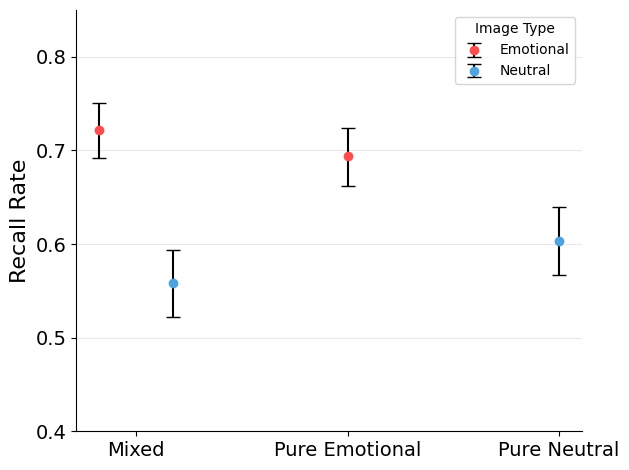

In [4]:
axis = plot_cat_recall_rate(
    datasets,
    trial_masks,
    category_field=category_field,
    category_values=category_values,
    valid_field=valid_field,
    labels=trial_labels,
    category_labels=category_labels,
    color_cycle=color_cycle,
    contrast_name=contrast_name,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
if yticks is not None:
    for ax in plt.gcf().axes:
        ax.set_yticks(yticks)

save_figure(figure_dir, figure_str)


In [5]:
def comparison_cell_label(trial_index, category_index):
    trial_label = trial_labels[trial_index]
    category_label = category_labels[category_index]
    if category_label in trial_label:
        return trial_label
    return f"{trial_label} {category_label}"


def subject_ids_for_mask(data, trial_mask):
    subjects = np.asarray(data["subject"]).reshape(-1)
    trial_mask = np.asarray(trial_mask).reshape(-1).astype(bool)
    return np.array([
        subject for subject in np.unique(subjects)
        if np.any((subjects == subject) & trial_mask)
    ])


def cell_values_by_subject(subject_ids_by_trial, subject_rates, cell):
    trial_index, category_index = cell
    subject_ids = subject_ids_by_trial[trial_index]
    values = np.asarray(subject_rates[trial_index][:, category_index], dtype=float)
    return {
        int(subject): float(value)
        for subject, value in zip(subject_ids, values)
        if np.isfinite(value)
    }


def contrast_of_contrasts_values(subject_ids_by_trial, subject_rates, left_a, left_b, right_a, right_b):
    cells = [left_a, left_b, right_a, right_b]
    value_maps = [
        cell_values_by_subject(subject_ids_by_trial, subject_rates, cell)
        for cell in cells
    ]
    common_subjects = sorted(set.intersection(*(set(values) for values in value_maps)))
    scores = np.array([
        (value_maps[0][subject] - value_maps[1][subject])
        - (value_maps[2][subject] - value_maps[3][subject])
        for subject in common_subjects
    ], dtype=float)
    return common_subjects, scores


def print_contrast_of_contrasts(label, scores, left_a, left_b, right_a, right_b):
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]
    print(f"\n{'='*70}")
    print(f"Contrast-of-Contrasts Test: {label}")
    print(f"{'='*70}")
    print(
        "Formula: "
        f"({comparison_cell_label(*left_a)} - {comparison_cell_label(*left_b)}) - "
        f"({comparison_cell_label(*right_a)} - {comparison_cell_label(*right_b)})"
    )
    print("Contrast-of-contrasts tests compare whether one category difference differs from another category difference.")
    print(f"n = {len(scores)}")
    if len(scores) == 0:
        print("Mean Diff-in-Diff = nan")
        print("t-stat = nan, t p-val = nan")
        print("W-stat = nan, W p-val = nan")
        print("95% CI = [nan, nan]")
        return

    mean_score = float(np.nanmean(scores))
    print(f"Mean Diff-in-Diff = {mean_score:.4f}")
    if len(scores) > 1:
        t_stat, t_pval = stats.ttest_1samp(scores, 0.0, nan_policy="omit")
        ci_low, ci_high = stats.t.interval(
            0.95,
            len(scores) - 1,
            loc=mean_score,
            scale=stats.sem(scores, nan_policy="omit"),
        )
    else:
        t_stat, t_pval = np.nan, np.nan
        ci_low, ci_high = np.nan, np.nan

    try:
        w_stat, w_pval = stats.wilcoxon(scores, alternative="two-sided")
    except ValueError:
        w_stat, w_pval = np.nan, np.nan

    print(f"t-stat = {float(t_stat):.3f}, t p-val = {float(t_pval):.4f}")
    print(f"W-stat = {float(w_stat):.1f}, W p-val = {float(w_pval):.4f}")
    print(f"95% CI = [{float(ci_low):.4f}, {float(ci_high):.4f}]")


raw_subject_rates = [
    subject_cat_recall_rate(
        data,
        mask,
        category_field,
        category_values,
        valid_field=valid_field,
    )
    for mask in trial_masks
]
raw_subject_ids = [subject_ids_for_mask(data, mask) for mask in trial_masks]

raw_means = np.array([np.nanmean(rates, axis=0) for rates in raw_subject_rates])
print("Raw subject-level means")
for trial_label, means in zip(trial_labels, raw_means):
    formatted = ", ".join(
        f"{category_label}: {mean:.4f}"
        for category_label, mean in zip(category_labels, means)
        if np.isfinite(mean)
    )
    print(f"{trial_label}: {formatted}")

for label, left_trial, left_cat, right_trial, right_cat in comparisons:
    result = test_cat_recall_rate_pair(
        raw_subject_rates[left_trial][:, left_cat],
        raw_subject_rates[right_trial][:, right_cat],
        comparison_cell_label(left_trial, left_cat),
        comparison_cell_label(right_trial, right_cat),
    )
    print(f"\n{'='*70}")
    print(f"Statistical Test: {label}")
    print(f"{'='*70}")
    print(result)

for label, left_a, left_b, right_a, right_b in contrast_of_contrasts:
    _, scores = contrast_of_contrasts_values(
        raw_subject_ids,
        raw_subject_rates,
        left_a,
        left_b,
        right_a,
        right_b,
    )
    print_contrast_of_contrasts(label, scores, left_a, left_b, right_a, right_b)


Raw subject-level means
Mixed: Emotional: 0.7222, Neutral: 0.5583
Pure Emotional: Emotional: 0.6943
Pure Neutral: Neutral: 0.6030

Statistical Test: Mixed Emotional vs Mixed Neutral
Comparison: Mixed Emotional - Mixed Neutral
n = 123
Mean Diff = 0.1640
t-stat = 9.243, t p-val = 0.0000
W-stat = 772.0, W p-val = 0.0000

Statistical Test: Mixed Neutral vs Pure Neutral
Comparison: Mixed Neutral - Pure Neutral
n = 123
Mean Diff = -0.0447
t-stat = -2.569, t p-val = 0.0114
W-stat = 2209.5, W p-val = 0.0170

Statistical Test: Pure Emotional vs Pure Neutral
Comparison: Pure Emotional - Pure Neutral
n = 123
Mean Diff = 0.0913
t-stat = 6.028, t p-val = 0.0000
W-stat = 894.5, W p-val = 0.0000

Contrast-of-Contrasts Test: Mixed emotional advantage vs pure emotional advantage
Formula: (Mixed Emotional - Mixed Neutral) - (Pure Emotional - Pure Neutral)
Contrast-of-contrasts tests compare whether one category difference differs from another category difference.
n = 123
Mean Diff-in-Diff = 0.0726
t-sta

## Interpretation

The generic plot shows category recall rates for each selected trial group. Missing points indicate category cells with no valid studied items, such as neutral items in pure emotional lists.

Contrast-of-contrasts tests compare whether one category difference differs from another category difference.


## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset` with category fields.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for saved figures.
- `ylim` — y-axis limits for the generic point plot, or `None` for automatic scaling.
- `yticks` — y-axis ticks for the generic point plot, or `None` for automatic ticks.
- `trial_queries` — Python expressions evaluated against the dataset to select trial groups.
- `trial_labels` — x-axis labels for the trial groups.
- `category_field` — dataset field containing item category labels.
- `category_values` — category values to summarize.
- `category_labels` — legend labels for category values.
- `valid_field` — optional field with positive values at valid study positions.
- `contrast_of_contrasts` — optional contrast-of-contrasts tests, specified as `(label, left_a, left_b, right_a, right_b)` where each cell is `(trial_group_index, category_index)`.
